# RF com Balanceamento: SMOTE vs Undersampling
## Detecção de áreas queimadas — Landsat 8/9

Compara dois modelos Random Forest com estratégias de balanceamento de classes:

- **SMOTE** *(Synthetic Minority Oversampling Technique)*: gera amostras sintéticas da classe minoritária (queimada) interpolando vizinhos no espaço de features.
- **RandomUnderSampler**: remove aleatoriamente amostras da classe majoritária (não queimada) até equilibrar as proporções.

| | |
|---|---|
| **Treino** | cena `220_075` — Landsat 8 pré (21/08) / Landsat 9 pós (29/08) |
| **Teste cego** | cena `221_074` — Landsat 9 pré (20/08) / Landsat 8 pós (28/08) |
| **Features (10)** | B4/B5/B7 pré, B4/B5/B7 pós, ΔB4/ΔB5/ΔB7, BAI pós |
| **Visualização** | composto falsa-cor 7-5-4 pós-fogo + overlay de predições |


In [1]:
!pip install numpy matplotlib rasterio scikit-learn "imbalanced-learn"


In [2]:
from __future__ import annotations

import logging
import warnings
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import rasterio
from rasterio.warp import Resampling, reproject

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, cohen_kappa_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score,
    roc_auc_score, roc_curve,
)

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

warnings.filterwarnings("ignore", category=RuntimeWarning)
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger("rf_balanced")

RNG_SEED = 42
np.random.seed(RNG_SEED)

# Landsat Collection 2 Level-2 SR
LANDSAT_SCALE  = 0.0000275
LANDSAT_OFFSET = -0.2
DNBR_THRESHOLD = 0.065   # limiar que gerou as máscaras

FEATURE_NAMES = [
    "B4_pre", "B5_pre", "B7_pre",
    "B4_post", "B5_post", "B7_post",
    "dB4", "dB5", "dB7",
    "BAI_post",
]
N_FEATURES = len(FEATURE_NAMES)


In [3]:
@dataclass(frozen=True)
class LandsatScene:
    """Descritor de uma cena: bandas SR, máscara NBR e dNBR pré-calculado."""
    tag: str
    b4_pre:  Path; b5_pre:  Path; b7_pre:  Path
    b4_post: Path; b5_post: Path; b7_post: Path
    mask_nbr: Path
    dnbr: Path   # apenas para baseline — NÃO entra como feature


SCENE_TRAIN = LandsatScene(
    tag="220_075",
    b4_pre  = Path("220_075/img_pre/LC08_L2SP_220075_20240821_20240830_02_T1_SR_B4.tif"),
    b5_pre  = Path("220_075/img_pre/LC08_L2SP_220075_20240821_20240830_02_T1_SR_B5.tif"),
    b7_pre  = Path("220_075/img_pre/LC08_L2SP_220075_20240821_20240830_02_T1_SR_B7.tif"),
    b4_post = Path("220_075/img_pos/LC09_L2SP_220075_20240829_20240830_02_T1_SR_B4.tif"),
    b5_post = Path("220_075/img_pos/LC09_L2SP_220075_20240829_20240830_02_T1_SR_B5.tif"),
    b7_post = Path("220_075/img_pos/LC09_L2SP_220075_20240829_20240830_02_T1_SR_B7.tif"),
    mask_nbr= Path("220_075/mascara_0_1/mascara_1_0_areaqueimada_lim_0-65_nbr.tif"),
    dnbr    = Path("220_075/diferenca_pre_pos/LC08_220075_dif_nbr_pre_pos.tif"),
)

SCENE_TEST = LandsatScene(
    tag="221_074",
    b4_pre  = Path("221_074/img_pre/LC09_L2SP_221074_20240820_20240821_02_T1_SR_B4.tif"),
    b5_pre  = Path("221_074/img_pre/LC09_L2SP_221074_20240820_20240821_02_T1_SR_B5.tif"),
    b7_pre  = Path("221_074/img_pre/LC09_L2SP_221074_20240820_20240821_02_T1_SR_B7.tif"),
    b4_post = Path("221_074/img_pos/LC08_L2SP_221074_20240828_20240831_02_T1_SR_B4.tif"),
    b5_post = Path("221_074/img_pos/LC08_L2SP_221074_20240828_20240831_02_T1_SR_B5.tif"),
    b7_post = Path("221_074/img_pos/LC08_L2SP_221074_20240828_20240831_02_T1_SR_B7.tif"),
    mask_nbr= Path("221_074/mascara_0_1/mascara_1_0_areaqueimada_lim_0-65_nbr.tif"),
    dnbr    = Path("221_074/diferenca_pre_pos/LC09_221074_dif_nbr_pre_pos.tif"),
)

log.info("Treino : %s | Teste cego: %s", SCENE_TRAIN.tag, SCENE_TEST.tag)


12:02:57 [INFO] Treino : 220_075 | Teste cego: 221_074


In [4]:
def _warp(src_path: Path, ref_path: Path,
          resampling=Resampling.bilinear, src_nodata=None) -> np.ndarray:
    """Reprojeta raster para o grid (CRS + transform + shape) de ref_path."""
    with rasterio.open(ref_path) as ref:
        shape, transform, crs = ref.shape, ref.transform, ref.crs
    out = np.full(shape, np.nan, dtype=np.float32)
    with rasterio.open(src_path) as src:
        nd = src_nodata if src_nodata is not None else src.nodata
        reproject(
            source=rasterio.band(src, 1), destination=out,
            src_transform=src.transform, src_crs=src.crs,
            dst_transform=transform, dst_crs=crs,
            resampling=resampling, src_nodata=nd, dst_nodata=np.nan,
        )
    return out


def load_sr_band(src_path: Path, ref_path: Path) -> np.ndarray:
    """Carrega banda SR (UInt16), alinha ao grid de ref e converte para reflectância."""
    raw = _warp(src_path, ref_path, src_nodata=0)
    return np.where(np.isfinite(raw),
                    raw * LANDSAT_SCALE + LANDSAT_OFFSET,
                    np.nan).astype(np.float32)


def load_mask(path: Path) -> np.ndarray:
    """0 = não queimada | 1 = queimada | -1 = inválido."""
    with rasterio.open(path) as src:
        raw = src.read(1).astype(np.float32)
        nd  = src.nodata
    out = np.full(raw.shape, -1, dtype=np.int8)
    out[raw == 0] = 0
    out[raw == 1] = 1
    if nd is not None:
        out[raw == nd] = -1
    return out


def compute_bai(b4: np.ndarray, b5: np.ndarray) -> np.ndarray:
    """Burned Area Index (Chuvieco et al. 2002).
    1 / ((0.1 - ρRed)^2 + (0.06 - ρNIR)^2) — clampado em 500."""
    denom = (0.1 - b4) ** 2 + (0.06 - b5) ** 2
    bai = np.where(denom > 1e-8, 1.0 / denom, np.nan)
    return np.clip(bai, 0, 500).astype(np.float32)


def build_features(scene: LandsatScene) -> tuple[np.ndarray, np.ndarray]:
    """Carrega bandas SR, calcula as 10 features e retorna (cubo H×W×F, mask H×W)."""
    ref = scene.mask_nbr

    log.info("[%s] bandas pré-fogo...", scene.tag)
    b4_pre  = load_sr_band(scene.b4_pre,  ref)
    b5_pre  = load_sr_band(scene.b5_pre,  ref)
    b7_pre  = load_sr_band(scene.b7_pre,  ref)

    log.info("[%s] bandas pós-fogo...", scene.tag)
    b4_post = load_sr_band(scene.b4_post, ref)
    b5_post = load_sr_band(scene.b5_post, ref)
    b7_post = load_sr_band(scene.b7_post, ref)

    cube = np.stack([
        b4_pre, b5_pre, b7_pre,
        b4_post, b5_post, b7_post,
        (b4_pre - b4_post).astype(np.float32),
        (b5_pre - b5_post).astype(np.float32),
        (b7_pre - b7_post).astype(np.float32),
        compute_bai(b4_post, b5_post),
    ], axis=-1)  # (H, W, 10)

    log.info("[%s] máscara NBR...", scene.tag)
    mask = load_mask(ref)
    log.info("[%s] features=%s | mask=%s", scene.tag, cube.shape, mask.shape)
    return cube, mask


def flatten_valid(cube: np.ndarray, mask: np.ndarray):
    """Vetoriza e remove pixels com NaN ou máscara=-1.
    Retorna (X float32, y int8, valid_flat_idx bool)."""
    Xf = cube.reshape(-1, N_FEATURES)
    yf = mask.ravel()
    valid = (yf >= 0) & np.all(np.isfinite(Xf), axis=1)
    return Xf[valid], yf[valid].astype(np.int8), valid


In [5]:
def evaluate(y_true, y_pred, y_proba=None, *, header=""):
    """Calcula métricas e devolve dict. Imprime se header fornecido."""
    m = {
        "Accuracy":  accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall":    recall_score(y_true, y_pred, zero_division=0),
        "F1":        f1_score(y_true, y_pred, zero_division=0),
        "Kappa":     cohen_kappa_score(y_true, y_pred),
    }
    if y_proba is not None:
        m["ROC-AUC"] = roc_auc_score(y_true, y_proba)
    if header:
        print(f"\n=== {header} ===")
        for k, v in m.items():
            print(f"  {k:<10}: {v:.4f}")
    return m


def compare_table(named: dict) -> None:
    """Tabela comparativa linhas=métricas × colunas=modelos."""
    keys = ["Accuracy", "Precision", "Recall", "F1", "Kappa", "ROC-AUC"]
    cw = 15
    header = f"{'Métrica':<11}" + "".join(f"{n:>{cw}}" for n in named)
    print("\n" + header)
    print("-" * len(header))
    for k in keys:
        row = f"{k:<11}" + "".join(
            f"{m.get(k, float('nan')):>{cw}.4f}" for m in named.values()
        )
        print(row)


def batch_predict(model, X: np.ndarray, *, chunk=500_000, label=""):
    """Predição em chunks para cenas com dezenas de milhões de pixels."""
    n = X.shape[0]
    preds = np.empty(n, dtype=np.int8)
    proba = np.empty(n, dtype=np.float32)
    for s in range(0, n, chunk):
        e = min(s + chunk, n)
        preds[s:e] = model.predict(X[s:e]).astype(np.int8)
        proba[s:e] = model.predict_proba(X[s:e])[:, 1]
        if label:
            log.info("%s: %d/%d (%.0f%%)", label, e, n, 100 * e / n)
    return preds, proba


In [6]:
def make_false_color(scene: LandsatScene, p_low=2, p_high=98) -> np.ndarray:
    """Composto falsa-cor 7-5-4 (SWIR2|NIR|Red) a partir das bandas locais.
    Queimadas → vermelho/laranja | Vegetação → verde | Água → azul escuro."""
    ref = scene.mask_nbr
    bands = [
        load_sr_band(scene.b7_post, ref),  # R ← SWIR2
        load_sr_band(scene.b5_post, ref),  # G ← NIR
        load_sr_band(scene.b4_post, ref),  # B ← Red
    ]
    rgb = np.zeros((*bands[0].shape, 3), dtype=np.uint8)
    for i, b in enumerate(bands):
        valid_vals = b[np.isfinite(b)]
        lo, hi = np.percentile(valid_vals, [p_low, p_high])
        rgb[..., i] = np.clip(
            (b - lo) / max(hi - lo, 1e-9) * 255, 0, 255
        ).astype(np.uint8)
    return rgb


def make_pred_map(pred_flat: np.ndarray,
                  valid_idx: np.ndarray, H: int, W: int) -> np.ndarray:
    """Reconstrói mapa 2D de predição a partir do vetor de pixels válidos."""
    full = np.full(H * W, -1, dtype=np.int8)
    full[valid_idx] = pred_flat
    return full.reshape(H, W)


def overlay_errors(rgb: np.ndarray, pred_map: np.ndarray,
                   truth_map: np.ndarray, alpha: float = 0.55) -> np.ndarray:
    """Sobrepõe mapa de erros ao RGB:
    Verde  (#00d23c) → TP (queimada correta)
    Laranja (#ff9600) → FP (alarme falso)
    Vermelho (#dc0000) → FN (queimada perdida)"""
    out = rgb.astype(np.float32)
    valid = (truth_map >= 0) & (pred_map >= 0)
    for mask, color in [
        (valid & (pred_map == 1) & (truth_map == 1), [0,   210,  60]),
        (valid & (pred_map == 1) & (truth_map == 0), [255, 150,   0]),
        (valid & (pred_map == 0) & (truth_map == 1), [220,   0,   0]),
    ]:
        out[mask] = (1 - alpha) * out[mask] + alpha * np.array(color, float)
    return out.clip(0, 255).astype(np.uint8)


def legend_patches():
    return [
        mpatches.Patch(color="#ff0000", label="TP — queimada correta"),
        mpatches.Patch(color="#ff9600", label="FP — alarme falso"),
        mpatches.Patch(color="#0004ff", label="FN — queimada perdida"),
    ]


## 1. Cena de Treino — `220_075`

Carrega as 10 features e a máscara NBR.


In [7]:
log.info("=" * 60)
log.info("Carregando cena de treino: %s", SCENE_TRAIN.tag)
log.info("=" * 60)

cube_tr, mask_tr = build_features(SCENE_TRAIN)
H_tr, W_tr = mask_tr.shape
total_tr = mask_tr.size

n_burn   = int((mask_tr == 1).sum())
n_unburn = int((mask_tr == 0).sum())
n_inv    = int((mask_tr == -1).sum())

log.info(
    "Grade: %d×%d  |  queimada=%d (%.2f%%)  não queimada=%d (%.2f%%)  inválido=%d (%.2f%%)",
    H_tr, W_tr,
    n_burn,   100 * n_burn   / total_tr,
    n_unburn, 100 * n_unburn / total_tr,
    n_inv,    100 * n_inv    / total_tr,
)


12:02:58 [INFO] ============================================================
12:02:58 [INFO] Carregando cena de treino: 220_075
12:02:58 [INFO] ============================================================
12:02:58 [INFO] [220_075] bandas pré-fogo...
12:03:03 [INFO] [220_075] bandas pós-fogo...
12:03:11 [INFO] [220_075] máscara NBR...
12:03:12 [INFO] [220_075] features=(7691, 7581, 10) | mask=(7691, 7581)
12:03:13 [INFO] Grade: 7691×7581  |  queimada=3199001 (5.49%)  não queimada=37274412 (63.93%)  inválido=17832058 (30.58%)


12:03:15 [INFO] Pixels válidos: 40473413 (69.42%)


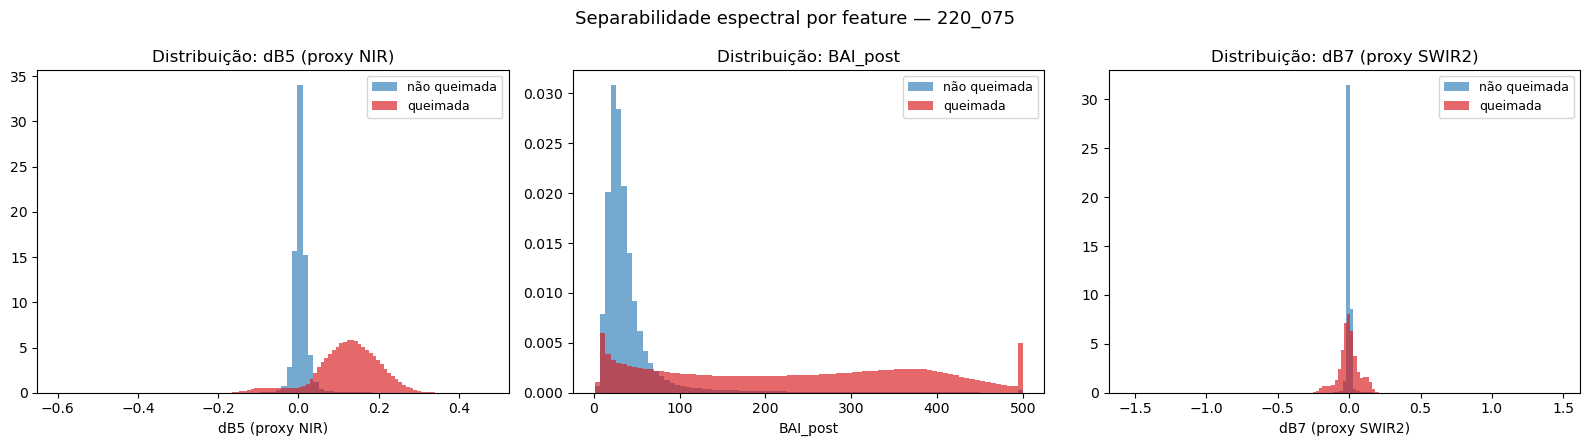

In [8]:
X_all, y_all, valid_tr = flatten_valid(cube_tr, mask_tr)
log.info("Pixels válidos: %d (%.2f%%)", len(y_all), 100 * len(y_all) / total_tr)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
show_feats = [("dB5 (proxy NIR)", 7), ("BAI_post", 9), ("dB7 (proxy SWIR2)", 8)]

for ax, (fname, fidx) in zip(axes, show_feats):
    for cls, color, lbl in [
        (0, "#2c7bb6", "não queimada"),
        (1, "#d7191c", "queimada"),
    ]:
        ax.hist(X_all[y_all == cls, fidx],
                bins=80, alpha=0.65, color=color,
                label=lbl, density=True)
    ax.set_title(f"Distribuição: {fname}")
    ax.set_xlabel(fname)
    ax.legend(fontsize=9)

plt.suptitle(f"Separabilidade espectral por feature — {SCENE_TRAIN.tag}", fontsize=13)
plt.tight_layout()
plt.show()


## 2. Baseline e Preparação dos Dados

### Baseline
Threshold fixo `dNBR > 0.065` — o mesmo limiar usado para gerar as máscaras.
Qualquer modelo precisa superar esse número para justificar a complexidade adicional.

### Divisão treino / holdout
1. Split estratificado 70/30 **antes** do balanceamento para o holdout ser imparcial.
2. Subamostragem de 50 k pixels do pool de dev (mantendo proporção de classes).
3. Balanceamento aplicado **somente** no conjunto de dev, nunca no holdout.


In [9]:
# Baseline na cena de treino
dnbr_tr_arr  = _warp(SCENE_TRAIN.dnbr, SCENE_TRAIN.mask_nbr)
dnbr_tr_flat = dnbr_tr_arr.ravel()[valid_tr]
y_base_all   = (dnbr_tr_flat > DNBR_THRESHOLD).astype(np.int8)

metrics_base_all = evaluate(
    y_all, y_base_all,
    header=f"Baseline dNBR>{DNBR_THRESHOLD} — cena treino {SCENE_TRAIN.tag}",
)

# Split estratificado 70/30
X_dev, X_hold, y_dev, y_hold, dnbr_dev, dnbr_hold = train_test_split(
    X_all, y_all, dnbr_tr_flat,
    test_size=0.30, stratify=y_all, random_state=RNG_SEED,
)

# Subamostragem do pool de dev para 50k
SUBSAMPLE = 50_000
if X_dev.shape[0] > SUBSAMPLE:
    X_sub, _, y_sub, _ = train_test_split(
        X_dev, y_dev,
        train_size=SUBSAMPLE, stratify=y_dev, random_state=RNG_SEED,
    )
else:
    X_sub, y_sub = X_dev, y_dev

log.info(
    "Sub-amostra para balanceamento: %d px  (queimada=%.2f%%)",
    len(y_sub), 100 * y_sub.mean(),
)
log.info(
    "Holdout intocado: %d px  (queimada=%.2f%%)",
    len(y_hold), 100 * y_hold.mean(),
)



=== Baseline dNBR>0.065 — cena treino 220_075 ===
  Accuracy  : 1.0000
  Precision : 1.0000
  Recall    : 1.0000
  F1        : 1.0000
  Kappa     : 1.0000


12:04:01 [INFO] Sub-amostra para balanceamento: 50000 px  (queimada=7.90%)
12:04:01 [INFO] Holdout intocado: 12142024 px  (queimada=7.90%)


## 3. Modelo A — SMOTE (Oversampling)

O SMOTE gera pixels sintéticos da classe **queimada** interpolando k-vizinhos
no espaço de features. Com `sampling_strategy=1.0`, a classe queimada é
expandida até igualar a não-queimada.

> **Atenção**: pixeis sintéticos não correspondem a localizações reais no terreno.
> O modelo aprende fronteiras de decisão baseadas em combinações lineares de
> espectros reais — útil para aumentar a cobertura do espaço de features, mas pode
> gerar amostras fora da distribuição real em bordas de queimada.


In [10]:
log.info("Aplicando SMOTE...")
smote = SMOTE(sampling_strategy=1.0, random_state=RNG_SEED)
X_sm, y_sm = smote.fit_resample(X_sub, y_sub)
log.info(
    "Após SMOTE: %d px | queimada=%d (%.1f%%)  não queimada=%d (%.1f%%)",
    len(y_sm), y_sm.sum(), 100 * y_sm.mean(),
    (y_sm == 0).sum(), 100 * (y_sm == 0).mean(),
)

rf_smote = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=1,
    max_features="sqrt",
    class_weight=None,   # balanceamento externo via SMOTE
    bootstrap=True,
    oob_score=True,
    n_jobs=-1,
    random_state=RNG_SEED,
)
rf_smote.fit(X_sm, y_sm)
log.info("RF-SMOTE treinado | OOB score: %.4f", rf_smote.oob_score_)

pred_sm_hold, proba_sm_hold = batch_predict(
    rf_smote, X_hold, label=f"holdout SMOTE ({SCENE_TRAIN.tag})"
)
metrics_sm_hold = evaluate(
    y_hold, pred_sm_hold, proba_sm_hold,
    header=f"RF-SMOTE — holdout {SCENE_TRAIN.tag}",
)

12:04:01 [INFO] Aplicando SMOTE...
12:04:01 [INFO] Após SMOTE: 92096 px | queimada=46048 (50.0%)  não queimada=46048 (50.0%)
12:04:15 [INFO] RF-SMOTE treinado | OOB score: 0.9975
12:04:18 [INFO] holdout SMOTE (220_075): 500000/12142024 (4%)
12:04:20 [INFO] holdout SMOTE (220_075): 1000000/12142024 (8%)
12:04:23 [INFO] holdout SMOTE (220_075): 1500000/12142024 (12%)
12:04:25 [INFO] holdout SMOTE (220_075): 2000000/12142024 (16%)
12:04:27 [INFO] holdout SMOTE (220_075): 2500000/12142024 (21%)
12:04:30 [INFO] holdout SMOTE (220_075): 3000000/12142024 (25%)
12:04:32 [INFO] holdout SMOTE (220_075): 3500000/12142024 (29%)
12:04:35 [INFO] holdout SMOTE (220_075): 4000000/12142024 (33%)
12:04:37 [INFO] holdout SMOTE (220_075): 4500000/12142024 (37%)
12:04:40 [INFO] holdout SMOTE (220_075): 5000000/12142024 (41%)
12:04:42 [INFO] holdout SMOTE (220_075): 5500000/12142024 (45%)
12:04:44 [INFO] holdout SMOTE (220_075): 6000000/12142024 (49%)
12:04:47 [INFO] holdout SMOTE (220_075): 6500000/1214202


=== RF-SMOTE — holdout 220_075 ===
  Accuracy  : 0.9950
  Precision : 0.9475
  Recall    : 0.9923
  F1        : 0.9694
  Kappa     : 0.9667
  ROC-AUC   : 0.9998


## 4. Modelo B — RandomUnderSampler (Undersampling)

O undersampler descarta aleatoriamente pixels da classe **não-queimada** até
a proporção solicitada. Com `sampling_strategy=1.0`, sobra um conjunto
perfeitamente balanceado com ~2× menos amostras que o SMOTE.

> **Atenção**: perdemos informação real da classe majoritária. Em datasets com
> muitos pixels disponíveis (como imagens Landsat), o impacto costuma ser baixo —
> mas o modelo pode tornar-se overconfiante em regiões com fenologia incomum
> que foram sub-amostradas.


In [11]:
log.info("Aplicando RandomUnderSampler...")
rus = RandomUnderSampler(sampling_strategy=1.0, random_state=RNG_SEED)
X_us, y_us = rus.fit_resample(X_sub, y_sub)
log.info(
    "Após Undersampling: %d px | queimada=%d (%.1f%%)  não queimada=%d (%.1f%%)",
    len(y_us), y_us.sum(), 100 * y_us.mean(),
    (y_us == 0).sum(), 100 * (y_us == 0).mean(),
)

rf_under = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=1,
    max_features="sqrt",
    class_weight=None,   # balanceamento externo via undersampling
    bootstrap=True,
    oob_score=True,
    n_jobs=-1,
    random_state=RNG_SEED,
)
rf_under.fit(X_us, y_us)
log.info("RF-Under treinado | OOB score: %.4f", rf_under.oob_score_)

pred_us_hold, proba_us_hold = batch_predict(
    rf_under, X_hold, label=f"holdout Under ({SCENE_TRAIN.tag})"
)
metrics_us_hold = evaluate(
    y_hold, pred_us_hold, proba_us_hold,
    header=f"RF-Under — holdout {SCENE_TRAIN.tag}",
)


12:05:20 [INFO] Aplicando RandomUnderSampler...
12:05:20 [INFO] Após Undersampling: 7904 px | queimada=3952 (50.0%)  não queimada=3952 (50.0%)
12:05:21 [INFO] RF-Under treinado | OOB score: 0.9904
12:05:23 [INFO] holdout Under (220_075): 500000/12142024 (4%)
12:05:25 [INFO] holdout Under (220_075): 1000000/12142024 (8%)
12:05:27 [INFO] holdout Under (220_075): 1500000/12142024 (12%)
12:05:29 [INFO] holdout Under (220_075): 2000000/12142024 (16%)
12:05:31 [INFO] holdout Under (220_075): 2500000/12142024 (21%)
12:05:33 [INFO] holdout Under (220_075): 3000000/12142024 (25%)
12:05:35 [INFO] holdout Under (220_075): 3500000/12142024 (29%)
12:05:37 [INFO] holdout Under (220_075): 4000000/12142024 (33%)
12:05:39 [INFO] holdout Under (220_075): 4500000/12142024 (37%)
12:05:41 [INFO] holdout Under (220_075): 5000000/12142024 (41%)
12:05:43 [INFO] holdout Under (220_075): 5500000/12142024 (45%)
12:05:45 [INFO] holdout Under (220_075): 6000000/12142024 (49%)
12:05:48 [INFO] holdout Under (220_075


=== RF-Under — holdout 220_075 ===
  Accuracy  : 0.9839
  Precision : 0.8311
  Recall    : 0.9991
  F1        : 0.9074
  Kappa     : 0.8986
  ROC-AUC   : 0.9994



=== Baseline — holdout ===
  Accuracy  : 1.0000
  Precision : 1.0000
  Recall    : 1.0000
  F1        : 1.0000
  Kappa     : 1.0000

COMPARAÇÃO — holdout interno 220_075

Métrica           Baseline       RF-SMOTE       RF-Under
--------------------------------------------------------
Accuracy            1.0000         0.9950         0.9839
Precision           1.0000         0.9475         0.8311
Recall              1.0000         0.9923         0.9991
F1                  1.0000         0.9694         0.9074
Kappa               1.0000         0.9667         0.8986
ROC-AUC                nan         0.9998         0.9994


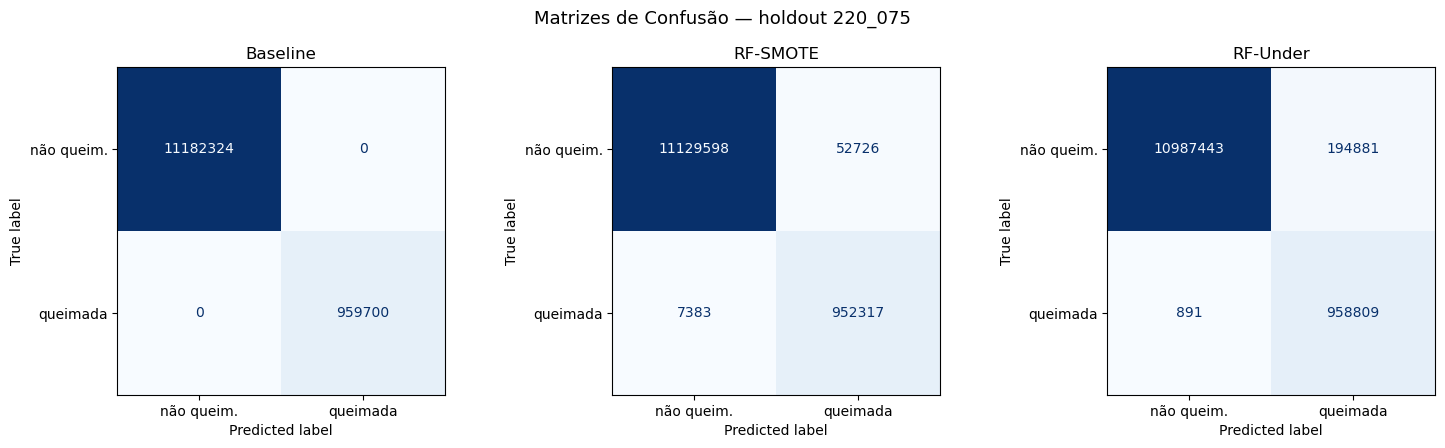

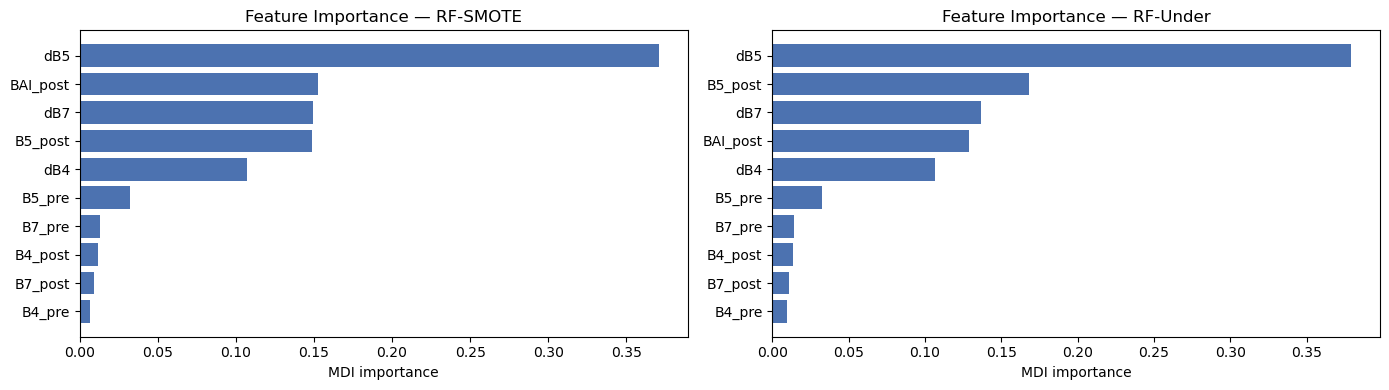

In [12]:
y_base_hold = (dnbr_hold > DNBR_THRESHOLD).astype(np.int8)
metrics_base_hold = evaluate(y_hold, y_base_hold,
                              header="Baseline — holdout")

print(f"\n{'='*60}")
print(f"COMPARAÇÃO — holdout interno {SCENE_TRAIN.tag}")
print(f"{'='*60}")
compare_table({
    "Baseline": metrics_base_hold,
    "RF-SMOTE": metrics_sm_hold,
    "RF-Under": metrics_us_hold,
})

# Matrizes de confusão
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
labels = ["não queim.", "queimada"]
for ax, (name, pred) in zip(axes, [
    ("Baseline",  y_base_hold),
    ("RF-SMOTE",  pred_sm_hold),
    ("RF-Under",  pred_us_hold),
]):
    ConfusionMatrixDisplay(
        confusion_matrix(y_hold, pred),
        display_labels=labels,
    ).plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
    ax.set_title(name, fontsize=12)

plt.suptitle(f"Matrizes de Confusão — holdout {SCENE_TRAIN.tag}", fontsize=13)
plt.tight_layout()
plt.show()

# Importância de features
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (name, model) in zip(axes, [("RF-SMOTE", rf_smote), ("RF-Under", rf_under)]):
    order = np.argsort(model.feature_importances_)
    ax.barh(np.arange(N_FEATURES),
            model.feature_importances_[order],
            color="#4c72b0")
    ax.set_yticks(np.arange(N_FEATURES))
    ax.set_yticklabels([FEATURE_NAMES[i] for i in order])
    ax.set_xlabel("MDI importance")
    ax.set_title(f"Feature Importance — {name}")

plt.tight_layout()
plt.show()


## 5. Cena de Teste Cego — `221_074`

Aplicamos os modelos numa cena nunca vista durante o ajuste. Sensor, data e
fenologia são diferentes — este é o teste real de generalização.

> **Nota**: a cena 221_074 apresenta baixa concordância entre máscara NBR e
> NDVI (~1% de interseção). Usamos a máscara NBR como ground truth (consistente
> com os notebooks anteriores), mas o mapa de erros deve ser interpretado
> com cautela.


In [13]:
log.info("=" * 60)
log.info("Carregando cena de teste cego: %s", SCENE_TEST.tag)
log.info("=" * 60)

cube_te, mask_te = build_features(SCENE_TEST)
H_te, W_te = mask_te.shape

X_te, y_te, valid_te = flatten_valid(cube_te, mask_te)
log.info(
    "Grade: %d×%d  |  válidos=%d (%.2f%%)  queimada=%.2f%%",
    H_te, W_te, len(y_te),
    100 * len(y_te) / (H_te * W_te), 100 * y_te.mean(),
)


12:06:23 [INFO] ============================================================
12:06:23 [INFO] Carregando cena de teste cego: 221_074
12:06:23 [INFO] ============================================================
12:06:23 [INFO] [221_074] bandas pré-fogo...
12:06:28 [INFO] [221_074] bandas pós-fogo...
12:06:36 [INFO] [221_074] máscara NBR...
12:06:37 [INFO] [221_074] features=(7821, 7721, 10) | mask=(7821, 7721)
12:06:39 [INFO] Grade: 7821×7721  |  válidos=40137022 (66.47%)  queimada=4.89%


In [14]:
# Predição com ambos os modelos
pred_sm_te, proba_sm_te = batch_predict(
    rf_smote, X_te, label=f"teste SMOTE ({SCENE_TEST.tag})"
)
pred_us_te, proba_us_te = batch_predict(
    rf_under, X_te, label=f"teste Under ({SCENE_TEST.tag})"
)

# Baseline na cena de teste
dnbr_te_arr  = _warp(SCENE_TEST.dnbr, SCENE_TEST.mask_nbr)
dnbr_te_flat = dnbr_te_arr.ravel()[valid_te]
pred_base_te = (dnbr_te_flat > DNBR_THRESHOLD).astype(np.int8)

m_base_te = evaluate(y_te, pred_base_te,
                      header=f"Baseline dNBR>{DNBR_THRESHOLD} — cena cega {SCENE_TEST.tag}")
m_sm_te   = evaluate(y_te, pred_sm_te, proba_sm_te,
                      header=f"RF-SMOTE — cena cega {SCENE_TEST.tag}")
m_us_te   = evaluate(y_te, pred_us_te, proba_us_te,
                      header=f"RF-Under — cena cega {SCENE_TEST.tag}")

print(f"\n{'='*60}")
print(f"COMPARAÇÃO — cena cega {SCENE_TEST.tag}")
print(f"{'='*60}")
compare_table({
    "Baseline": m_base_te,
    "RF-SMOTE": m_sm_te,
    "RF-Under": m_us_te,
})


12:06:41 [INFO] teste SMOTE (221_074): 500000/40137022 (1%)
12:06:43 [INFO] teste SMOTE (221_074): 1000000/40137022 (2%)
12:06:46 [INFO] teste SMOTE (221_074): 1500000/40137022 (4%)
12:06:48 [INFO] teste SMOTE (221_074): 2000000/40137022 (5%)
12:06:50 [INFO] teste SMOTE (221_074): 2500000/40137022 (6%)
12:06:52 [INFO] teste SMOTE (221_074): 3000000/40137022 (7%)
12:06:55 [INFO] teste SMOTE (221_074): 3500000/40137022 (9%)
12:06:57 [INFO] teste SMOTE (221_074): 4000000/40137022 (10%)
12:06:59 [INFO] teste SMOTE (221_074): 4500000/40137022 (11%)
12:07:01 [INFO] teste SMOTE (221_074): 5000000/40137022 (12%)
12:07:03 [INFO] teste SMOTE (221_074): 5500000/40137022 (14%)
12:07:05 [INFO] teste SMOTE (221_074): 6000000/40137022 (15%)
12:07:08 [INFO] teste SMOTE (221_074): 6500000/40137022 (16%)
12:07:10 [INFO] teste SMOTE (221_074): 7000000/40137022 (17%)
12:07:12 [INFO] teste SMOTE (221_074): 7500000/40137022 (19%)
12:07:14 [INFO] teste SMOTE (221_074): 8000000/40137022 (20%)
12:07:16 [INFO] 


=== Baseline dNBR>0.065 — cena cega 221_074 ===
  Accuracy  : 1.0000
  Precision : 1.0000
  Recall    : 1.0000
  F1        : 1.0000
  Kappa     : 1.0000

=== RF-SMOTE — cena cega 221_074 ===
  Accuracy  : 0.9966
  Precision : 0.9471
  Recall    : 0.9857
  F1        : 0.9660
  Kappa     : 0.9643
  ROC-AUC   : 0.9998

=== RF-Under — cena cega 221_074 ===
  Accuracy  : 0.9912
  Precision : 0.8484
  Recall    : 0.9986
  F1        : 0.9174
  Kappa     : 0.9128
  ROC-AUC   : 0.9996

COMPARAÇÃO — cena cega 221_074

Métrica           Baseline       RF-SMOTE       RF-Under
--------------------------------------------------------
Accuracy            1.0000         0.9966         0.9912
Precision           1.0000         0.9471         0.8484
Recall              1.0000         0.9857         0.9986
F1                  1.0000         0.9660         0.9174
Kappa               1.0000         0.9643         0.9128
ROC-AUC                nan         0.9998         0.9996


## 6. Visualização — Falsa-cor + Overlay de Predições

**Composição 7-5-4** (SWIR2 | NIR | Red) da imagem pós-fogo:
- Vermelho/Laranja → áreas com alta reflectância em SWIR2 e baixa em NIR (cicatrizes de queimada)
- Verde → vegetação saudável (alta reflectância NIR)
- Azul escuro → água

**Cores do overlay**:
- 🟢 Verde — TP: queimada corretamente detectada
- 🟠 Laranja — FP: alarme falso (não queimada classificada como queimada)
- 🔴 Vermelho — FN: queimada real perdida pelo modelo


In [15]:
log.info("Construindo composto falsa-cor 7-5-4 — %s", SCENE_TEST.tag)
rgb_te = make_false_color(SCENE_TEST)

# Reconstrói mapas 2D no grid da máscara
map_base = make_pred_map(pred_base_te, valid_te, H_te, W_te)
map_sm   = make_pred_map(pred_sm_te,   valid_te, H_te, W_te)
map_us   = make_pred_map(pred_us_te,   valid_te, H_te, W_te)

# Overlays de erro sobre o RGB
ov_base = overlay_errors(rgb_te, map_base, mask_te)
ov_sm   = overlay_errors(rgb_te, map_sm,   mask_te)
ov_us   = overlay_errors(rgb_te, map_us,   mask_te)

log.info("Imagens prontas.")


12:12:56 [INFO] Construindo composto falsa-cor 7-5-4 — 221_074
12:13:06 [INFO] Imagens prontas.


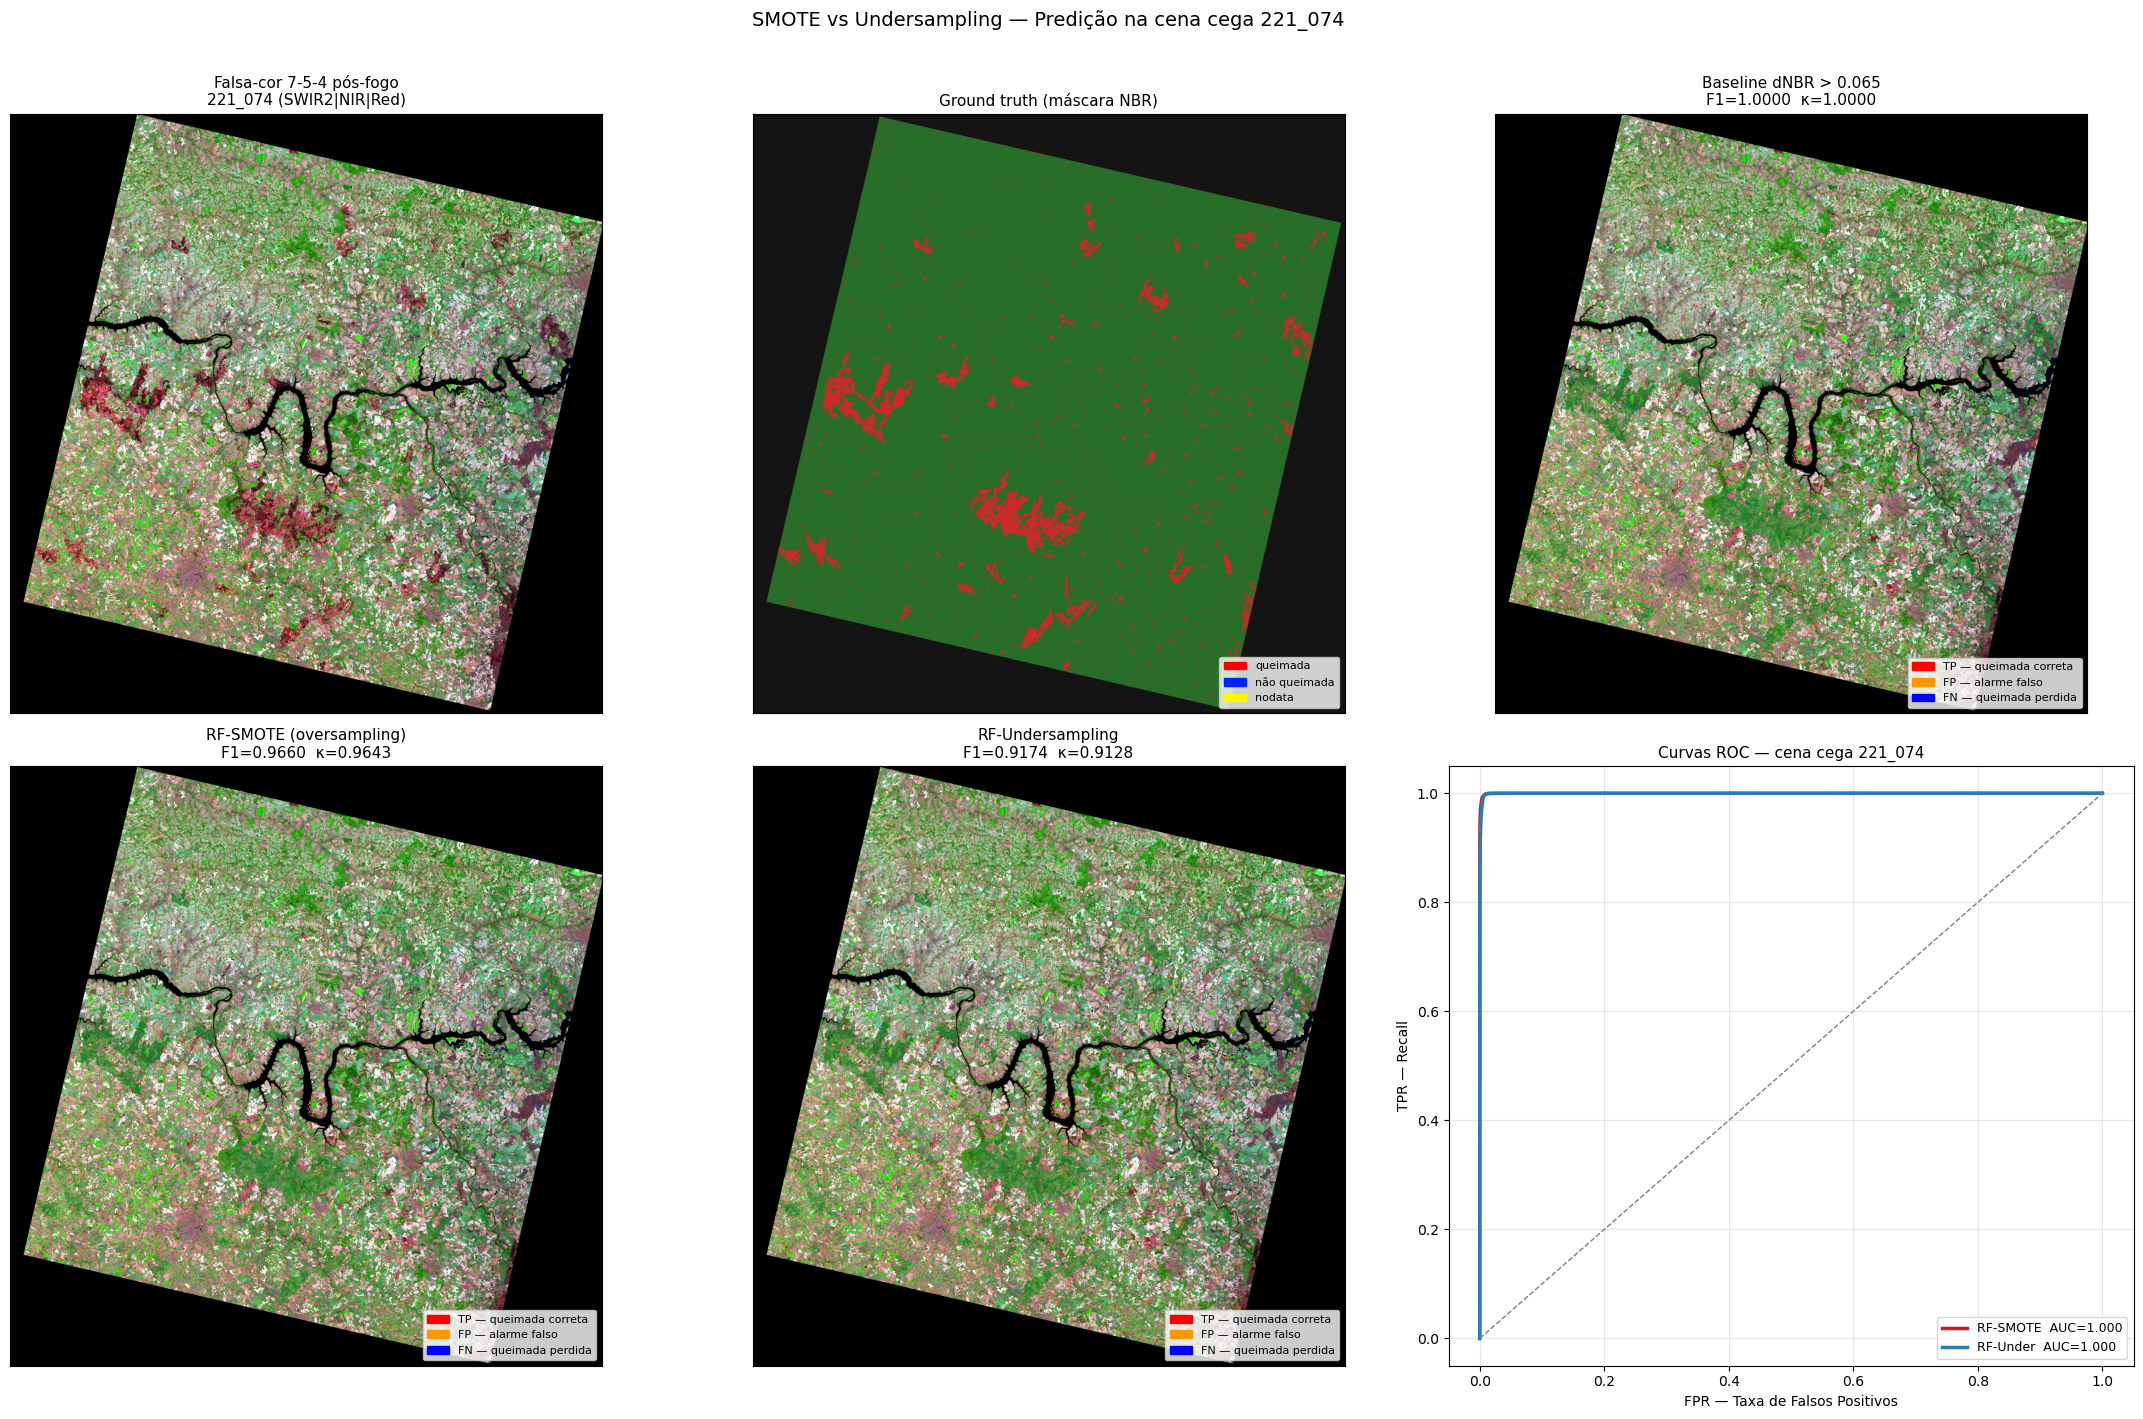

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(22, 14))

# ── linha 0 ──────────────────────────────────────────────────
axes[0, 0].imshow(rgb_te)
axes[0, 0].set_title(
    f"Falsa-cor 7-5-4 pós-fogo\n{SCENE_TEST.tag} (SWIR2|NIR|Red)", fontsize=11
)

# Ground truth
gt_rgb = np.zeros((*mask_te.shape, 3), dtype=np.uint8)
gt_rgb[mask_te ==  1] = [210,  40,  40]   # queimada
gt_rgb[mask_te ==  0] = [ 40, 110,  40]   # não queimada
gt_rgb[mask_te == -1] = [ 20,  20,  20]   # inválido / nodata
axes[0, 1].imshow(gt_rgb)
axes[0, 1].set_title("Ground truth (máscara NBR)", fontsize=11)
axes[0, 1].legend(
    handles=[
        mpatches.Patch(color="#f60404", label="queimada"),
        mpatches.Patch(color="#0022ff", label="não queimada"),
        mpatches.Patch(color="#FFF700", label="nodata"),
    ],
    loc="lower right", fontsize=8,
)

# Baseline
axes[0, 2].imshow(ov_base)
axes[0, 2].set_title(
    f"Baseline dNBR > {DNBR_THRESHOLD}\n"
    f"F1={m_base_te['F1']:.4f}  κ={m_base_te['Kappa']:.4f}", fontsize=11
)
axes[0, 2].legend(handles=legend_patches(), loc="lower right", fontsize=8)

# ── linha 1 ──────────────────────────────────────────────────
axes[1, 0].imshow(ov_sm)
axes[1, 0].set_title(
    f"RF-SMOTE (oversampling)\n"
    f"F1={m_sm_te['F1']:.4f}  κ={m_sm_te['Kappa']:.4f}", fontsize=11
)
axes[1, 0].legend(handles=legend_patches(), loc="lower right", fontsize=8)

axes[1, 1].imshow(ov_us)
axes[1, 1].set_title(
    f"RF-Undersampling\n"
    f"F1={m_us_te['F1']:.4f}  κ={m_us_te['Kappa']:.4f}", fontsize=11
)
axes[1, 1].legend(handles=legend_patches(), loc="lower right", fontsize=8)

# Curvas ROC
ax_roc = axes[1, 2]
for name, proba, color in [
    ("RF-SMOTE", proba_sm_te, "#d7191c"),
    ("RF-Under", proba_us_te, "#2c7bb6"),
]:
    fpr, tpr, _ = roc_curve(y_te, proba)
    auc = roc_auc_score(y_te, proba)
    ax_roc.plot(fpr, tpr, lw=2.5, color=color, label=f"{name}  AUC={auc:.3f}")
ax_roc.plot([0, 1], [0, 1], "--", color="gray", lw=1)
ax_roc.set_xlabel("FPR — Taxa de Falsos Positivos")
ax_roc.set_ylabel("TPR — Recall")
ax_roc.set_title(f"Curvas ROC — cena cega {SCENE_TEST.tag}", fontsize=11)
ax_roc.legend(loc="lower right", fontsize=9)
ax_roc.grid(alpha=0.3)
ax_roc.set_xticks(np.linspace(0, 1, 6))
ax_roc.set_yticks(np.linspace(0, 1, 6))

for ax in axes.ravel()[:5]:
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle(
    f"SMOTE vs Undersampling — Predição na cena cega {SCENE_TEST.tag}",
    fontsize=14, y=1.01,
)
plt.tight_layout()
plt.show()


## 7. O que interpretar nos resultados

| Sinal | Significado |
|---|---|
| F1 e κ parecidos entre SMOTE e Under | Balanceamento não é o gargalo; ambas as estratégias generalizam de forma similar. |
| SMOTE com Recall maior e Precision menor | O oversampling gerou pixels sintéticos que empurram o modelo para detectar mais queimadas (reduz FN mas aceita mais FP). |
| Under com Precision maior e Recall menor | O modelo treinado com menos dados tende a ser mais conservador — confirma queimada só quando o sinal é forte. |
| Muitos FN (vermelho) no mapa | Queimadas reais que o modelo não detectou; comum em áreas de baixa severidade (dNBR próximo do limiar). |
| Muitos FP (laranja) no mapa | Alarmes falsos; comum em solo exposto, sombra de nuvem, ou corpos d'água com reflectância anômala. |

### Próximos passos naturais
- **Calibrar o threshold de decisão** (prob > 0.5 é arbitrário) usando a curva ROC para balancear Precision/Recall conforme o objetivo.
- **Adicionar BAI calculado com bandas pré-corrigidas** (ao invés de usar os pixels brutos) para robustez cross-sensor L8/L9.
- **Validação espacial por blocos** dentro da cena de treino para penalizar autocorrelação.
- **Comparar com `class_weight="balanced"`** (sem sampling externo) como terceiro baseline.
